In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, fnmatch
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

# cosmologic model and constants
cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)
c=2.998*10**5

%matplotlib inline

In [2]:
# data path
lenstool_log_path = "/home/joao/Documents/Research/4_sys_analysis/LOG/"
pyautolens_log_path ="/home/joao/Documents/Research/4_sys_analysis/output/"

## RMS parameter

$\large RMS = \frac{1}{N} \sum_n \sqrt{(x_p^{n}-x_i^{n})^2 + (y_p^{n}-y_i^{n})^2}\,,$

Where

$\large (x_i, y_i)$ are input positions

$\large (x_p, y_p)$ are predicted positions

In [3]:
def get_rms(sys):
    """
    sys:path name
    """
    input_images = lenstool_log_path+sys+"/multfile.in"
    pred_images = lenstool_log_path+sys+"/image.dat"

    input_images_df = pd.read_csv(input_images,
                                  comment='#',
                                  usecols = [0,1,2],
                                  names=["type", "RA", "DEC"],
                                  sep=" ",
                                  index_col=False)
    input_images_df.head()

    pred_images_df = pd.read_csv(pred_images,
                                  comment='#',
                                  usecols = [0,1,2],
                                  names=["type", "RA", "DEC"],
                                  sep=" ",
                                  index_col=False)
    pred_images_df.head()

    types=input_images_df["type"]

    rms=[]
    for i in range(0, len(types)):
        pred_images_type_fix=pred_images_df[pred_images_df["type"]==types[i]]
        pred_images_type_fix.reset_index(drop=True, inplace=True)
        for j in range(0, len(pred_images_type_fix)):
            rms.append(np.sqrt((pred_images_type_fix["RA"][j]-input_images_df["RA"][i])**2+(pred_images_type_fix["DEC"][j]-input_images_df["DEC"][i])**2))

    return np.mean(rms)

In [5]:
def get_percentiles_lenstool(name, percentiles=[16, 50, 84]):
    """
    name: path of the system
    percentiles: percentiles for the statistics (remember: 50=average value)
    """
    # read the mcmc chain dataframe
    dataframe=pd.read_csv(lenstool_log_path+name+"/bayes.dat",
            comment='#',
            usecols = [1,2,3,4,5,6,7],
            names=["log", "x", "y", "e", "theta", "sigma", "chi2"],
            sep=" ",
            index_col=False)
    #return np.percentile(dataframe["x"], [16, 50, 84]), np.percentile(dataframe["y"], [16, 50, 84]), np.percentile(dataframe["e"], [16, 50, 84]), np.percentile(dataframe["theta"], [16, 50, 84]), np.percentile(dataframe["sigma"], [16, 50, 84])
    return np.percentile(dataframe["x"], [16, 50, 84]), np.percentile(dataframe["y"], [16, 50, 84]), np.percentile(dataframe["e"], [16, 50, 84]), np.percentile(dataframe["theta"], [16, 50, 84]), np.percentile(dataframe["sigma"], [16, 50, 84])


In [6]:
# to find the PyAutoLens path
def find(pattern, path):
    """
    pattern: file extension
    path: path of the file
    """
    result = []
    for root, dirs, files in os.walk(path):
        for name in files:
            if fnmatch.fnmatch(name, pattern):
                result.append(os.path.join(root, name))
    return result

## Parameter conversion:

## PyAutoLens $\large \rightarrow$ Lenstool

$\large (x_l, y_l, x_s, y_s, \xi_x, \xi_y, \theta_E) \rightarrow (x_l, y_l, \theta, \epsilon, \sigma_v)$ 

# Einstein Angle Conversion

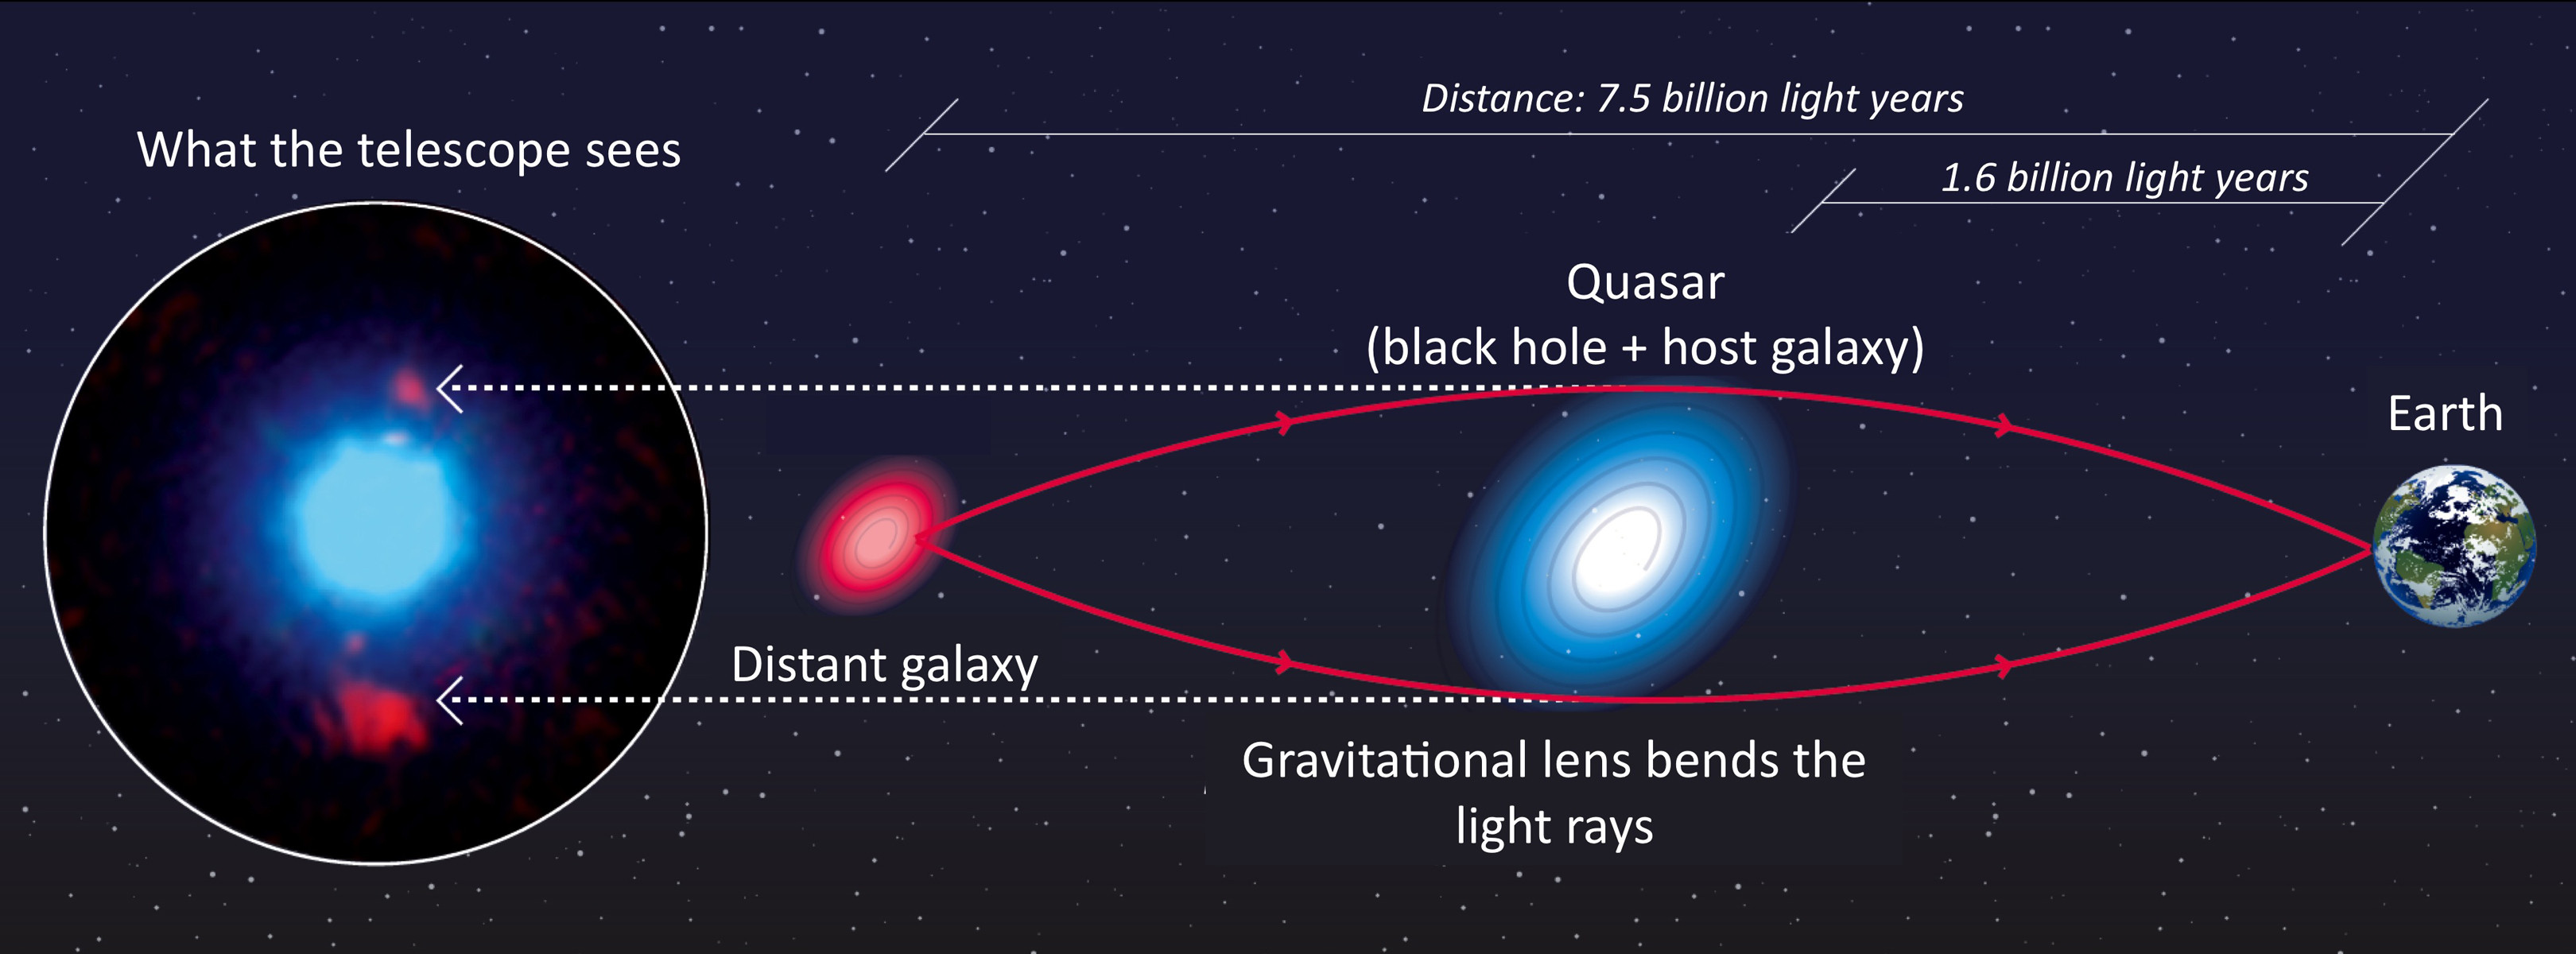

## Einstein Angle:
\begin{align}
\large\theta_E = \frac{4\pi \sigma_v^2}{c^2}\frac{D_A^{(LS)}}{D_A^{(s)}},
\end{align}
where $\large D_A(z) = \frac{1}{1+z}\frac{c}{H_0} \int^z_0 \frac{dz'}{E(z')}$.

Lens to source angular diameter distance:

\begin{align}
\large D_A^{(LS)} = \frac{1}{1+z_s} [D_m(z_s) - D_m(z_l)],
\end{align}

For $\large \Omega_k = 0$.


In [7]:
def convert_thetae_sigmav(z_l, z_s, theta_e):
    #arcsec to radians factor
    arcsec_to_rad_factor = 4.84814*10**(-6)
    theta_e_rad=theta_e*arcsec_to_rad_factor
    
    # lens to source angular diameter distance
    d_ls=cosmo.angular_diameter_distance_z1z2(z_l, z_s).value
    # source angular diameter distance
    d_s=cosmo.angular_diameter_distance(z_s).value
    # distance fraction
    factor=d_ls/d_s
    # sigma v conversion
    sigma_v = np.sqrt((c**2/(4*np.pi))*theta_e_rad*1/factor)
    return np.percentile(sigma_v, [16, 50, 84])

# Eccentricity and orientation angle

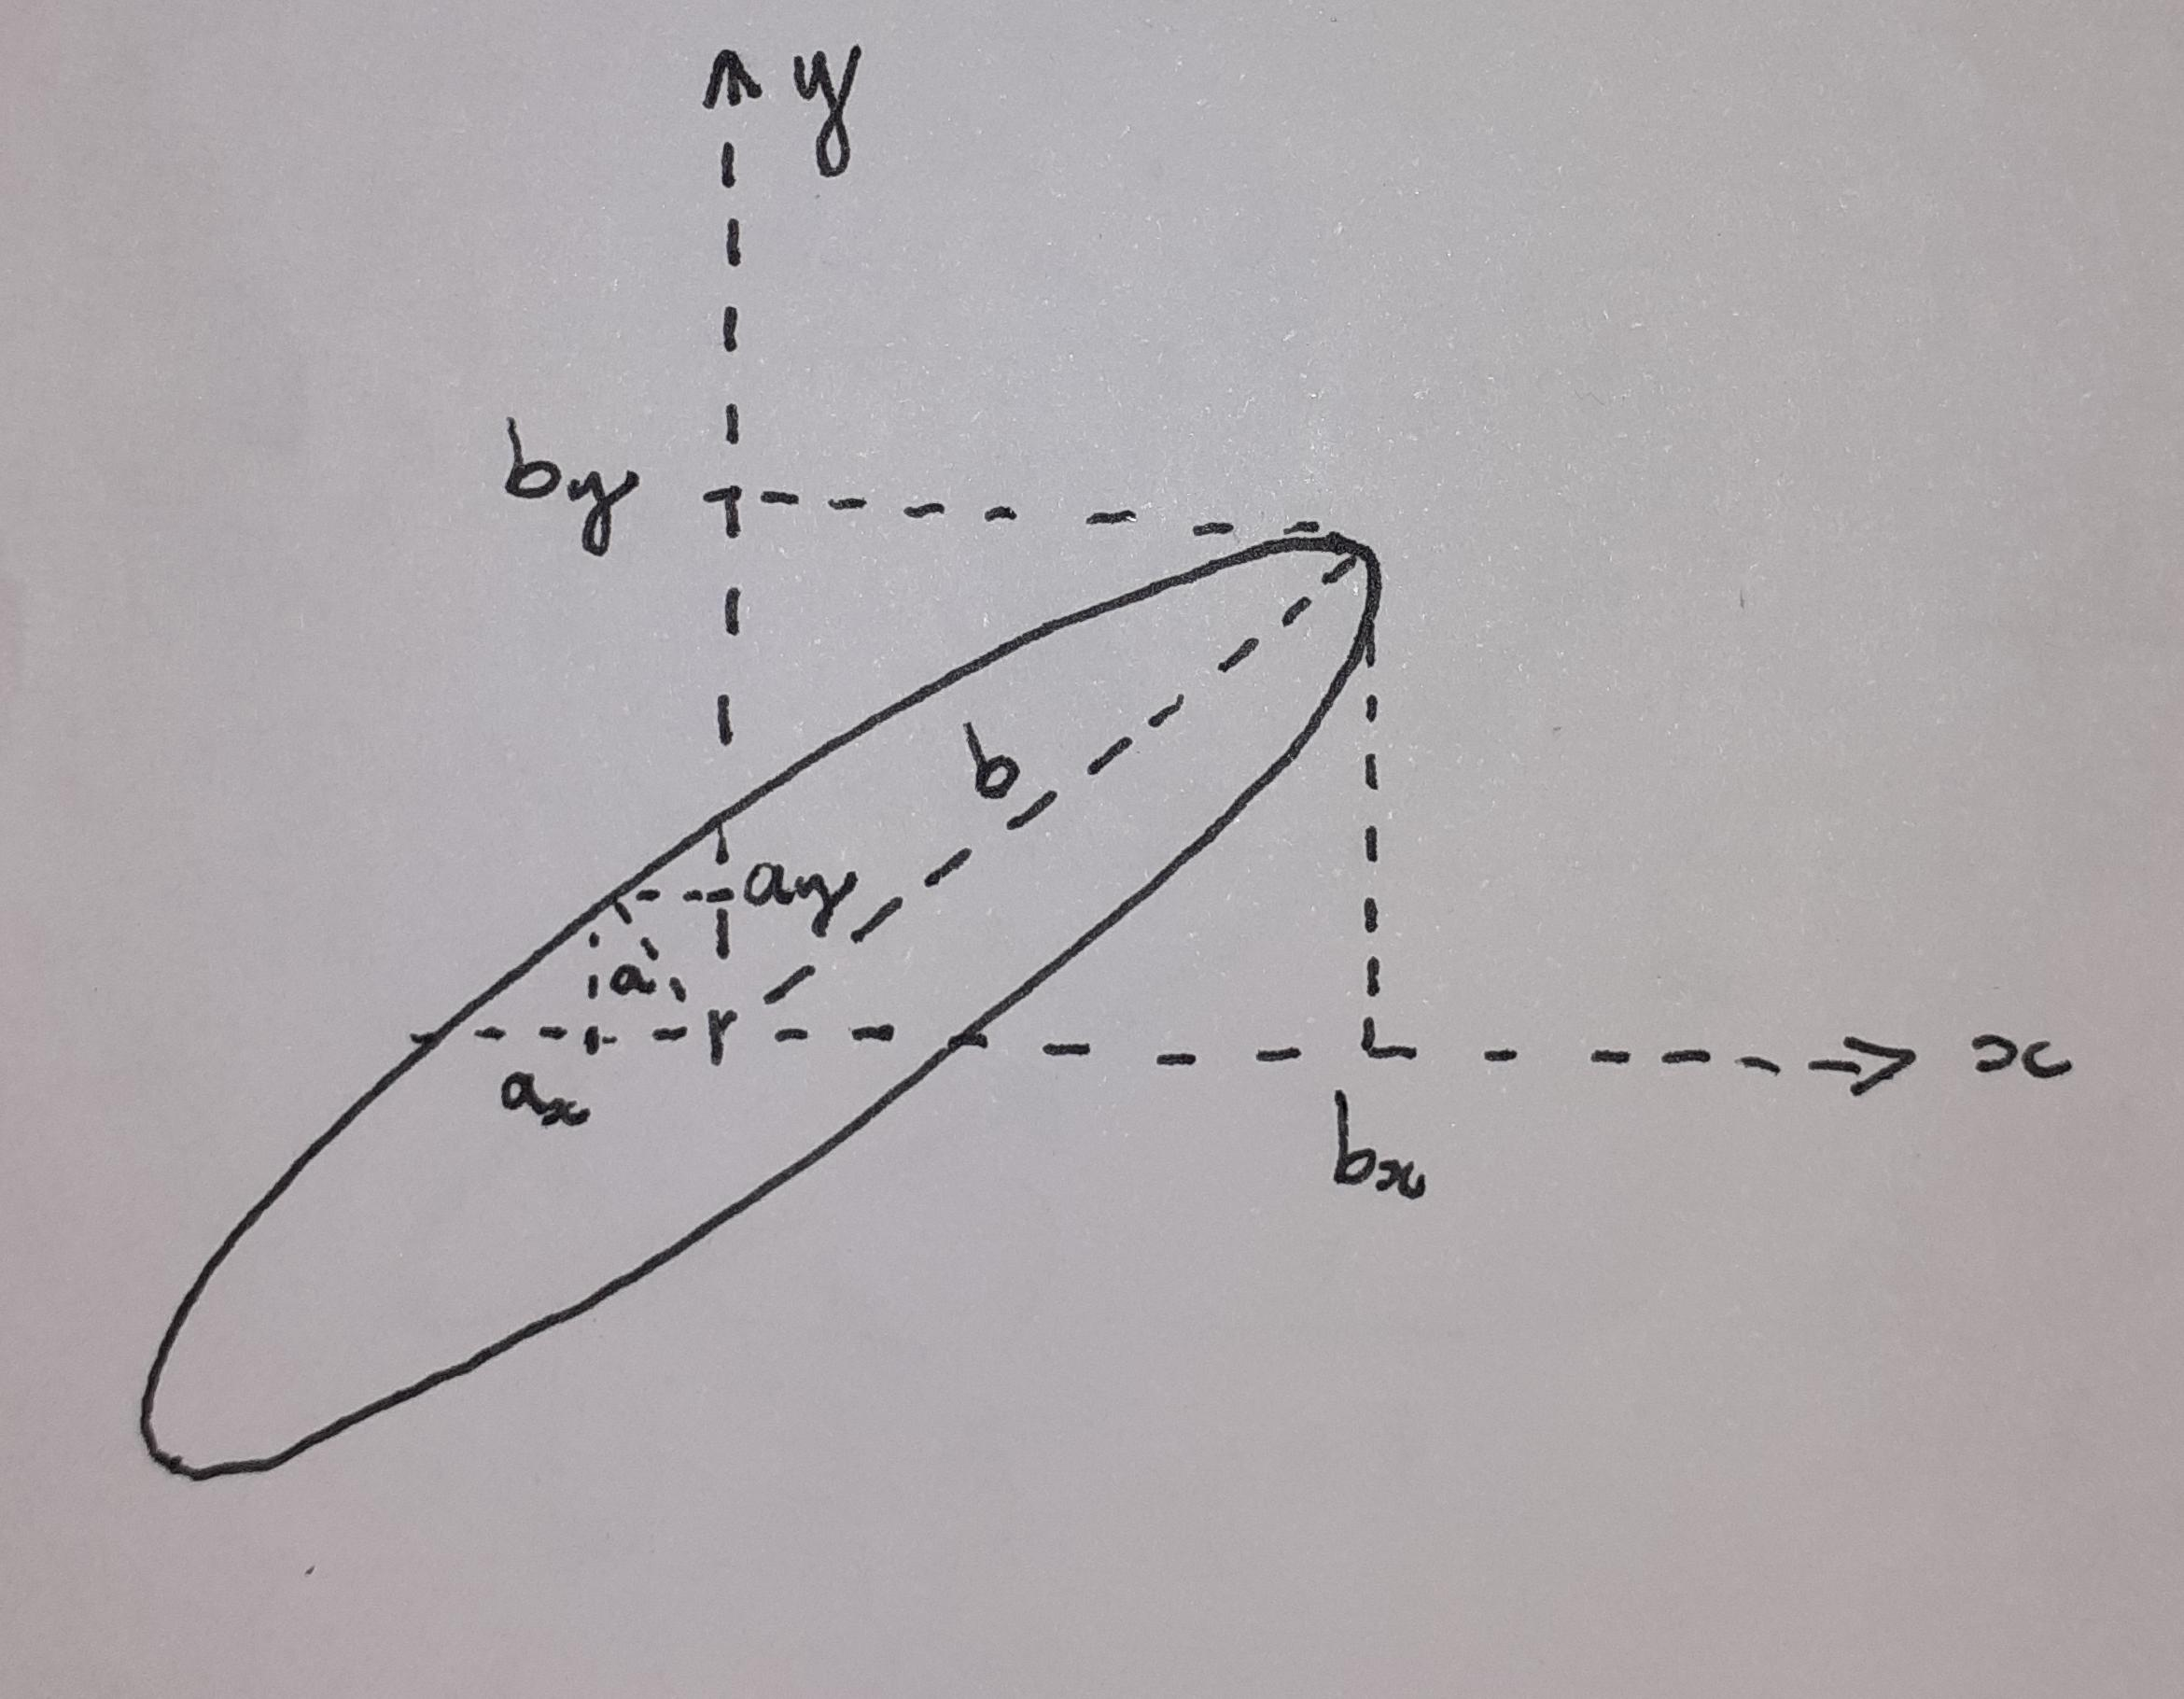

\begin{align}
\large\xi_x = \frac{1-q}{1+q} cos(2\theta)
\end{align}

\begin{align}
\large\xi_y = \frac{1-q}{1+q} sin(2\theta)
\end{align}

$\large q = \frac{1-\sqrt{\xi_x^2 + \xi_y^2}}{1+\sqrt{\xi_x^2 + \xi_y^2}}$

$\large \theta= \frac{1}{2} \arccos{\xi_x\frac{1+q}{1-q}}$

$\epsilon=\sqrt{1-q^2}$

In [8]:
def convert_ellcomp_exc_ang(ell_comp_x, ell_comp_y):
    """
    ell_comp_x: elliptical component x
    ell_comp_y: elliptical component y
    """
    # q parameter
    q=(1-np.sqrt(ell_comp_x**2+ell_comp_y**2))/(1+np.sqrt(ell_comp_x**2+ell_comp_y**2))
    # excentricity
    exc=np.sqrt(1-q**2)
    # orientation angle
    ang=0.5*np.arccos(ell_comp_x*(1+q)/(1-q))
    
    return exc, ang

In [9]:
def get_percentiles_pyautolens(name, percentiles=[16, 50, 84]):
    """
    name: path of the system
    percentiles: percentiles for the statistics (remember: 50=average value)
    """
    # mcmc chain dataframe path
    path_bayes=find('samples.csv', pyautolens_log_path+name)[0]
    # model results
    model_results_path=find('model.results', pyautolens_log_path+name)[0]
    # to read the lens and source redshift
    file=open(model_results_path)
    lines=file.readlines()
    file.close()
    # lens and source
    z_lens=float(lines[64][20:])
    z_source=1.0
    # PyAutoLens dataframe
    dataframe=pd.read_csv(path_bayes,
                          sep=",",
                          index_col=False)
    # Einstein angle percentiles
    theta_e = dataframe["galaxies_lens_mass_einstein_radius"]
    # convert the elliptical components into excentricity and angle 
    excentricity, angle = convert_ellcomp_exc_ang(dataframe["galaxies_lens_mass_elliptical_comps_1"], ell_comp_y=dataframe["galaxies_lens_mass_elliptical_comps_0"])
    # return x, y, e, theta, sigmav
    return np.percentile(dataframe["galaxies_lens_mass_centre_1"], [16, 50, 84]), np.percentile(dataframe["galaxies_lens_mass_centre_0"], [16, 50, 84]), np.percentile(excentricity, [16, 50, 84]), np.percentile(angle, [16, 50, 84]), convert_thetae_sigmav(z_lens, z_source, theta_e)


In [10]:
# Anna results path
anna_results_path = "/home/joao/Documents/Research/4_sys_analysis/LOG/results/anna_results.txt"

In [11]:
# Dataframe
anna_results=pd.read_csv(anna_results_path,
                         comment='#',
                         names=["x", "x_err", "y", "y_err", "e", "e_err", "theta", "theta_err", "sigma", "sigma_err", "sys"],
                         sep="\s+",
                         index_col=False)
anna_results.head()

,x,x_err,y,y_err,e,e_err,theta,theta_err,sigma,sigma_err,sys
0,0.71,0.08,0.05,0.11,0.11,0.008,9.28,1.30,440.58,1.40,1
1,0.72,0.08,0.04,0.15,0.08,0.120,4.90,24.95,434.59,2.96,1
2,0.53,0.09,-0.17,0.11,0.32,0.060,6.41,1.27,442.03,3.26,1
3,NaN,NaN,NaN,NaN,0.51,0.000,164.10,0.00,524.00,0.00,2
4,NaN,NaN,NaN,NaN,0.51,0.000,164.00,0.00,525.00,8.90,2


In [12]:
params_dict={
    1:"x",
    2:"y",
    3:"e",
    4:"theta",
    5:"sigma"
}
colorcode={
    0:"green",
    1:"k",
    2:"teal",
    3:"r",
    4:"blue",
    5:"purple"
}
legend={
    0:"Anna DS9",
    1:"Anna barycenter",
    2:"Anna Best Bright",
    3:"without counter image",
    4:"w/ counter image",
    5:"PyAutoLens"
}
param_latex_dict = {
    1:"x",
    2:"y",
    3:"e",
    4:"θ",
    5:"σ"
}

In [14]:
def confidence_plot(sys):
    """
    sys= system number eg. 1, 2, 3, 4
    """
    anna_result_sysfixed=anna_results[anna_results["sys"]==sys]
    anna_result_sysfixed.reset_index(drop=True, inplace=True)
    percentiles=get_percentiles_lenstool("sys_"+str(sys))
    percentiles_pyautolens=get_percentiles_pyautolens("sys"+str(sys))
    
    rms = get_rms("sys_"+str(sys))
    rms_ci = np.nan
    if int(sys) != 2:
        rms_ci = get_rms("sys_"+str(sys)+"_ci")
    
    fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)
    if sys != 2:
        percentiles_ci=get_percentiles_lenstool("sys_"+str(sys)+"_ci")
    
    for ii in range(1, 6):
        ax = fig.add_subplot(1, 6, ii)
        for jj in range(0, len(anna_result_sysfixed)):
            #print(anna_result_sysfixed[params_dict[ii]][jj])
            #print(np.array([anna_result_sysfixed[str(params_dict[ii])+"_err"][jj], anna_result_sysfixed[str(params_dict[ii])+"_err"][jj]]))
            if ii == 5:
                #print(legend[jj])
                ax.errorbar(float(anna_result_sysfixed[params_dict[ii]][jj]), jj, xerr=float(anna_result_sysfixed[str(params_dict[ii])+"_err"][jj]), fmt='o', c=str(colorcode[jj]), label=legend[jj])
            else:
                ax.errorbar(float(anna_result_sysfixed[params_dict[ii]][jj]), jj, xerr=float(anna_result_sysfixed[str(params_dict[ii])+"_err"][jj]), fmt='o', c=str(colorcode[jj]))

        if ii == 5:
            ax.errorbar(float(percentiles[ii-1][1]), jj+1, xerr=np.array([[float(percentiles[ii-1][1])-float(percentiles[ii-1][0])], [float(percentiles[ii-1][2])-float(percentiles[ii-1][1])]]), fmt='o', c=str(colorcode[jj+1]), label=legend[jj+1])
            if sys != 2:
                ax.errorbar(float(percentiles_ci[ii-1][1]), jj+2, xerr=np.array([[float(percentiles_ci[ii-1][1])-float(percentiles_ci[ii-1][0])], [float(percentiles_ci[ii-1][2])-float(percentiles_ci[ii-1][1])]]), fmt='o', c=str(colorcode[jj+2]), label=legend[jj+2])
            ax.errorbar(float(percentiles_pyautolens[ii-1][1]), jj+3, xerr=np.array([[float(percentiles_pyautolens[ii-1][1])-float(percentiles_pyautolens[ii-1][0])], [float(percentiles_pyautolens[ii-1][2])-float(percentiles_pyautolens[ii-1][1])]]), fmt='o', c=str(colorcode[jj+3]), label=legend[jj+3])
        else:
            ax.errorbar(float(percentiles[ii-1][1]), jj+1, xerr=np.array([[float(percentiles[ii-1][1])-float(percentiles[ii-1][0])], [float(percentiles[ii-1][2])-float(percentiles[ii-1][1])]]), fmt='o', c=str(colorcode[jj+1]))
            if sys !=2:
                ax.errorbar(float(percentiles_ci[ii-1][1]), jj+2, xerr=np.array([[float(percentiles_ci[ii-1][1])-float(percentiles_ci[ii-1][0])], [float(percentiles_ci[ii-1][2])-float(percentiles_ci[ii-1][1])]]), fmt='o', c=str(colorcode[jj+2]))     
            ax.errorbar(float(percentiles_pyautolens[ii-1][1]), jj+3, xerr=np.array([[float(percentiles_pyautolens[ii-1][1])-float(percentiles_pyautolens[ii-1][0])], [float(percentiles_pyautolens[ii-1][2])-float(percentiles_pyautolens[ii-1][1])]]), fmt='o', c=str(colorcode[jj+3]))
        
        plt.xlabel(param_latex_dict[ii])
        plt.yticks([])
        plt.rcParams.update({"font.size": 13})
        "{:.2e}".format(12300000)
    fig.suptitle("RMS: "+str("{:.2e}".format(round(float(rms), 5)))+" RMS w/ CI: "+str("{:.2e}".format(round(float(rms_ci), 5))))     
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5)

# CS82SL013639.16+000818.38

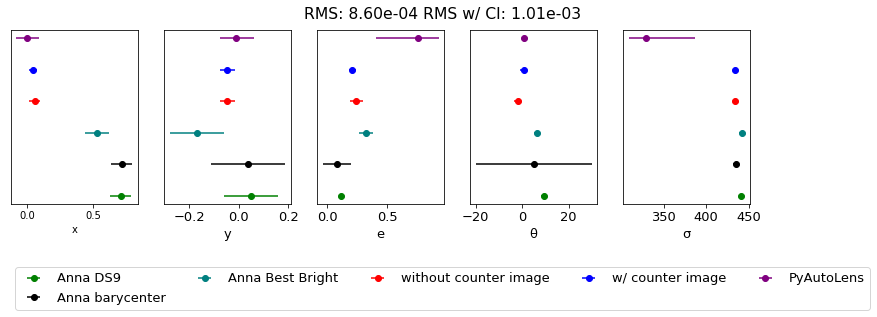

In [15]:
confidence_plot(1)

# CS82SL015824.81-003959.60

/home/joao/.local/lib/python3.8/site-packages/numpy/core/_asarray.py:102: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


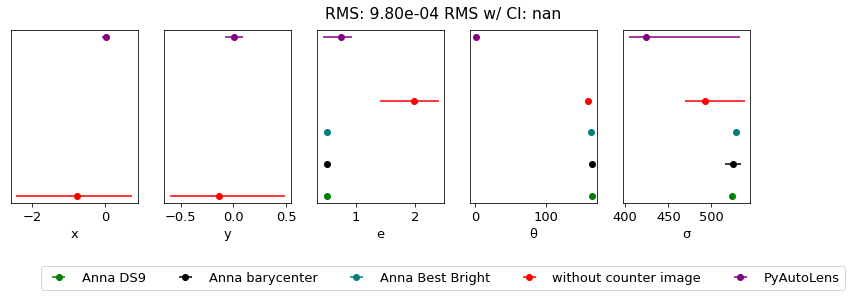

In [16]:
confidence_plot(2)

# CS82SL211527.25-003817.26

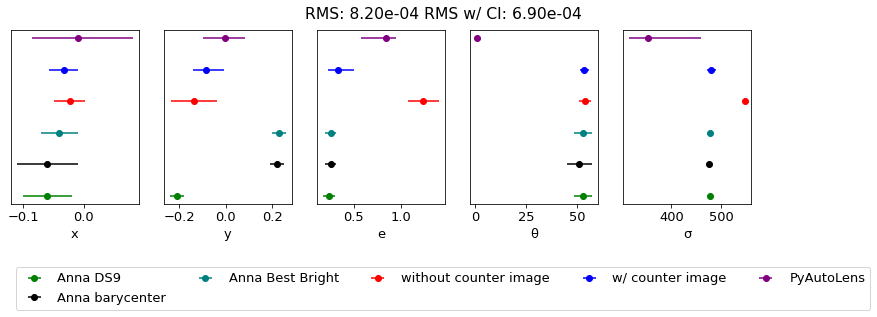

In [17]:
confidence_plot(3)

# CS82SL230521.68-000211.52

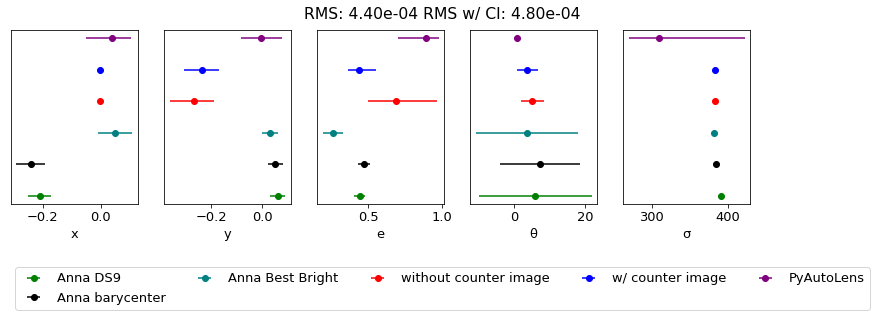

In [18]:
confidence_plot(4)